In [71]:
 !pip install pystokes

In [72]:
import numpy as np
import pystokes

from matplotlib import pyplot as plt
import matplotlib.patches as patches

import os

In [73]:
## System parameters
N  = 30           # number of beads
b  = 1.0          # bead radius
eta = 0.1         # fluid viscosity
Nf = 1            # number of filaments

bondLength    = 2 * b
springModulus = 500    # stretch stiffness (keep bonds rigid)
bendModulus   = 50     # kappa — bending stiffness
twistModulus  = 0

Lf = N * bondLength    #  length of filament

##  pystokes objects
rbm   = pystokes.unbounded.Rbm(radius=b, particles=N, viscosity=eta)
force = pystokes.forceFields.Forces(particles=N)

## Integration
dt      = 0.005
totTime = 600
Nt      = int(totTime / dt)

print(f"N={N} beads | L={Lf} | dt={dt} | steps={Nt}")

N=30 beads | L=60.0 | dt=0.005 | steps=120000


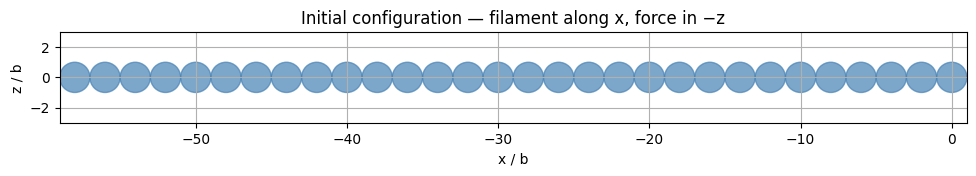

In [74]:
#Initial Configuration
#The filament starts straight, oriented along x, with force acting in −z (perpendicular to the rod axis).
position0 = np.zeros(3*N)
position0[0:N] = -np.arange(0, N) * bondLength   # beads along -x

fig, ax = plt.subplots(figsize=(10, 2))
x0, z0 = position0[0:N], position0[2*N:3*N]
for j in range(N):
    ax.add_patch(patches.Circle((x0[j], z0[j]), b, color='steelblue', alpha=0.7))
ax.set_xlim(np.min(x0) - b, np.max(x0) + b)
ax.set_ylim(-3*b, 3*b)
ax.set_aspect('equal'); ax.grid(True)
ax.set_xlabel('x / b'); ax.set_ylabel('z / b')
ax.set_title('Initial configuration — filament along x, force in −z')
plt.tight_layout(); plt.show()

In [75]:
#Right-hand side: equations of motion (oseen tensor and mobility)
def rhs(dX, position, Fg):
    """Compute displacement increment dX = v * dt."""
    F = np.zeros(3*N)
    v = np.zeros(3*N)
    # Internal elastic forces (bending + stretching)
    force.multipolymers(Nf, F, position, bondLength, springModulus, bendModulus, twistModulus)
    # External body force: Fg in -z on every bead
    F[2*N:3*N] -= Fg
    # Hydrodynamic mobility (Oseen tensor, non-local)
    rbm.mobilityTT(v, position, F)
    # dX = v * dt
    dX[:] = v * dt

In [76]:
#Simulation: Bending Amplitude vs B (Fig. 1)
#For each value of B, we run to steady state, then measure the transverse distortion amplitude:
#A=max(z)−min(z)
#and plot A/L vs B.
B_values = [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 2000,3000, 4000]

AmplitudeL  = []   # A/L at steady state
shapes      = {}   # store final shapes for insets
B_insets    = [10, 100, 500, 2000]   # B values for shape snapshots

for paramB in B_values:
    Fg       = paramB * bendModulus / (Lf**3)
    position = position0.copy()
    dX       = np.zeros(3*N)

    for i in range(Nt):
        rhs(dX, position, Fg)
        position += dX

    z = position[2*N:3*N]
    x = position[0:N]
    A = np.max(z) - np.min(z)
    AmplitudeL.append(A / Lf)

    if paramB in B_insets:
        shapes[paramB] = {'x': x - np.mean(x), 'z': z - np.mean(z)}

AmplitudeL = np.array(AmplitudeL)
print('Done. A/L values:', AmplitudeL)

Done. A/L values: [4.07387631e-04 8.14777233e-04 2.03697758e-03 4.07420158e-03
 8.15037460e-03 2.04104440e-02 4.10675104e-02 8.41032597e-02
 2.36326803e-01 3.76939796e-01 4.01114082e-01 4.06865401e-01
 4.09949342e-01]


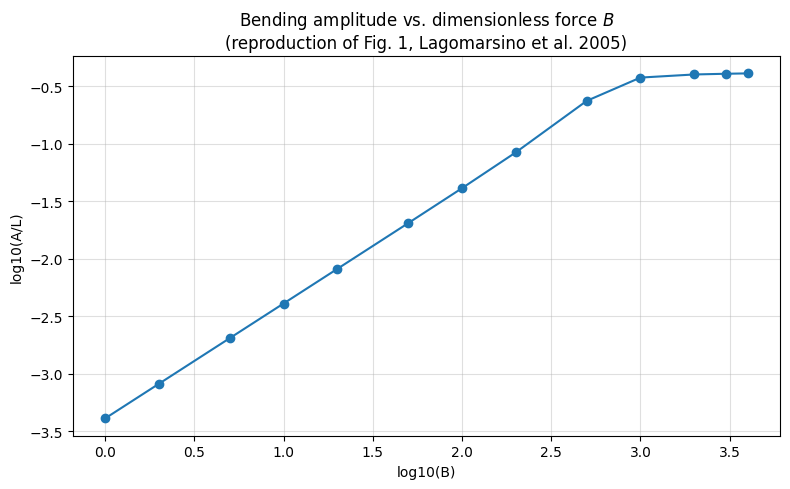

In [77]:
fig, ax = plt.subplots(figsize=(8, 5))
logB = np.log10(B_values)
logA = np.log10(AmplitudeL)

ax.plot(logB, logA, 'o-')
ax.set_xlabel('log10(B)')
ax.set_ylabel('log10(A/L)')
ax.set_title('Bending amplitude vs. dimensionless force $B$\n(reproduction of Fig. 1, Lagomarsino et al. 2005)', fontsize=12)
ax.grid(True, which='both', alpha=0.4)
plt.tight_layout()
plt.show()

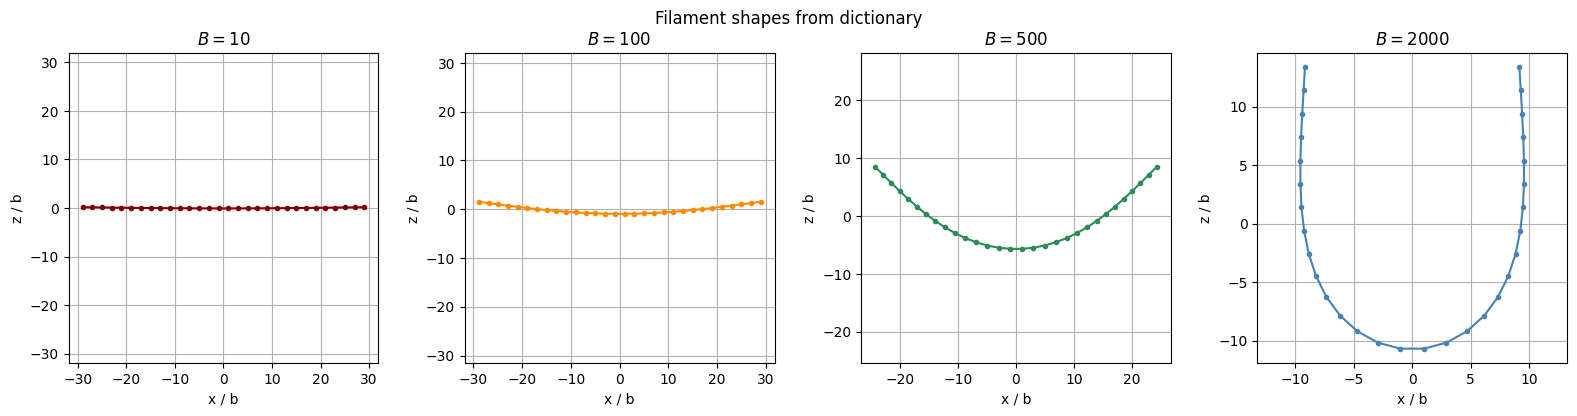

In [78]:
fig, axes = plt.subplots(1, len(B_insets), figsize=(16, 4))
colors = ['maroon', 'darkorange', 'seagreen', 'steelblue']

for ax, paramB, color in zip(axes, B_insets, colors):
    if paramB not in shapes:
        ax.set_title(f'B={paramB} (missing)')
        continue
    xc, zc = shapes[paramB]['x'], shapes[paramB]['z']
    ax.plot(xc, zc, 'o-', color=color, markersize=3, linewidth=1.5)
    ax.set_title(f'$B = {paramB}$')
    ax.set_aspect('equal')
    ax.set_box_aspect(1)
    ax.grid(True)
    ax.set_xlabel('x / b')
    ax.set_ylabel('z / b')

fig.suptitle('Filament shapes from dictionary')
plt.tight_layout()
plt.show()



In [79]:
## W-shape regime requires B >> 2000
paramB = 8000
Fg     = paramB * bendModulus / (Lf**3)
print(f'B = {paramB},  Fg per bead = {Fg:.6f}')

##  Initial condition: straight filament along x
position0       = np.zeros(3*N)
position0[0:N]  = -np.arange(0, N) * bondLength


dt      = 0.001
totTime = 60.0
Nt      = int(totTime / dt)
print(f'Steps: {Nt}')

## t=0  : straight
## t=27 : W shape (3 extrema in z profile)

snap_steps = {int(t/dt): t for t in [0, 27]}
shapes, pos = {}, position0.copy()

for i in range(Nt):
    if i in snap_steps:
        x, z = pos[0:N], pos[2*N:3*N]
        shapes[i] = (snap_steps[i], x - x.mean(), z - z.mean())
    F, v = np.zeros(3*N), np.zeros(3*N)
    force.multipolymers(Nf, F, pos, bondLength, springModulus, bendModulus, twistModulus)
    F[2*N:3*N] -= Fg; rbm.mobilityTT(v, pos, F); pos += v * dt


B = 8000,  Fg per bead = 1.851852
Steps: 60000


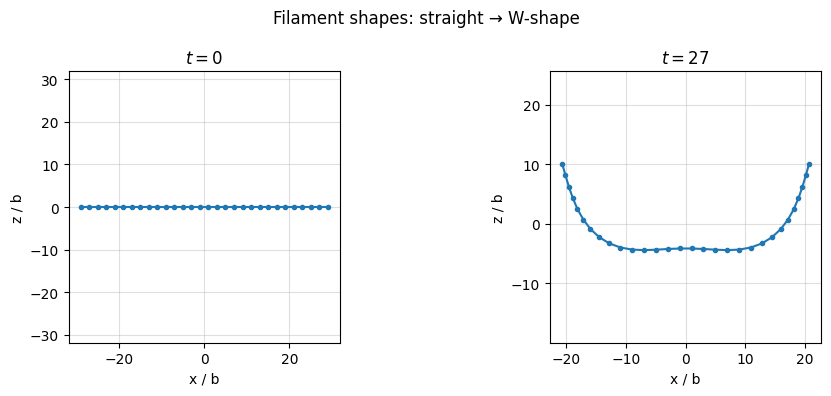

In [80]:

target_times = [0.0, 27.0]
plot_data = [(t, x, z) for step, (t, x, z) in shapes.items() if t in target_times]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (t, x, z) in zip(axes, plot_data):
    ax.plot(x, z, 'o-', markersize=3, linewidth=1.5)
    ax.set_title(f'$t = {t}$')
    ax.set_aspect('equal')
    ax.set_box_aspect(1)
    ax.grid(True, alpha=0.4)
    ax.set_xlabel('x / b')
    ax.set_ylabel('z / b')

fig.suptitle('Filament shapes: straight → W-shape')
plt.tight_layout()
plt.show()

In [81]:
# Stiff-limit friction (slender-body theory)
gamma0 = 4 * np.pi * eta * Lf / np.log(Lf / b)

# compute friction ratio for one B value
def friction_ratio(B):
    Fg = B * bendModulus / Lf**3
    pos = position0.copy()
    dX = np.zeros(3*N)

    # Run to steady state
    for _ in range(Nt):
        rhs(dX, pos, Fg)
        pos += dX

    # Compute CM velocity at steady state
    F = np.zeros(3*N); v = np.zeros(3*N)
    force.multipolymers(Nf, F, pos, bondLength, springModulus, bendModulus, twistModulus)
    F[2*N:3*N] -= Fg
    rbm.mobilityTT(v, pos, F)
    v_cm = np.mean(v[2*N:3*N])

    # gamma = F_total / |v_cm|, return ratio to stiff limit
    return (N * Fg) / (abs(v_cm) * gamma0) if abs(v_cm) > 1e-12 else 1.0

# Sweep B values
B_fric = [0.1, 0.5, 1, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 2000, 4000, 8000]
fric_ratio = np.array([friction_ratio(B) for B in B_fric])
print('Friction ratios:', np.round(fric_ratio, 4))

Friction ratios: [0.9119 0.9119 0.9119 0.9119 0.9119 0.9119 0.9119 0.9118 0.9117 0.9112
 0.908  0.8965 0.8549 0.7523 0.7202]


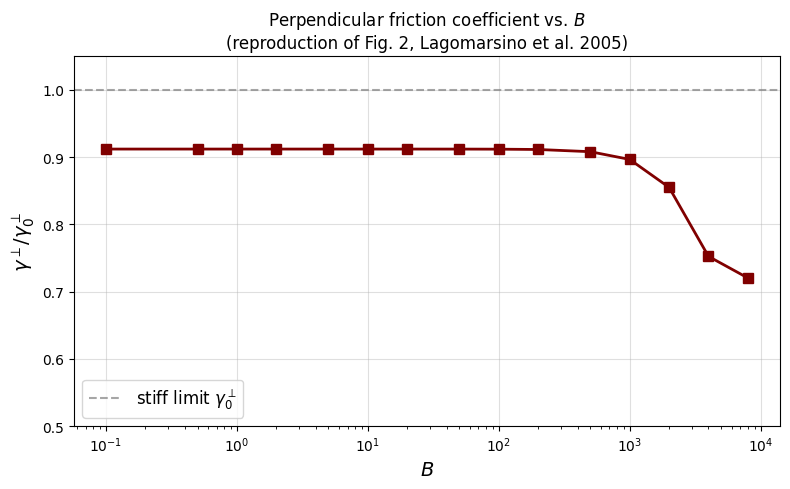

In [82]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.semilogx(B_fric, fric_ratio, 's-', color='maroon', linewidth=2, markersize=7)

ax.axhline(1.0, color='gray', linestyle='--', alpha=0.7, label='stiff limit $\\gamma^\\perp_0$')
ax.set_xlabel('$B$', fontsize=14)
ax.set_ylabel('$\\gamma^\\perp / \\gamma^\\perp_0$', fontsize=14)
ax.set_title('Perpendicular friction coefficient vs. $B$\n(reproduction of Fig. 2, Lagomarsino et al. 2005)', fontsize=12)
ax.legend(fontsize=12)
ax.grid(alpha=0.4)
ax.set_ylim(0.5, 1.05)

plt.tight_layout()
plt.show()